### Importing Packages

In [208]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [209]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import Subset

In [210]:
import matplotlib.pyplot as plt
import numpy as np

In [211]:
from tqdm import tqdm 

In [212]:
import random

In [213]:
from scipy.optimize import linear_sum_assignment

In [214]:
import copy

In [215]:
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

### Seed

In [216]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Importing Data

In [217]:
# Transform images to tensors
transform = transforms.ToTensor()

# Load training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

### Helper Functions

In [218]:
def filter_data(dataset, allowed_digits):

    """
    The function filter_data generates a subset of the given MNIST dataset consisting of all and only all of
    the images of digits in allowed_digits

    Args:
        dataset: MNIST dataset 
        allowed_digits: list of digits to look for in dataset

    Returns:
        filtered_dataset: MNIST subset of dataset consisting of all and only all digits in allowed_digits
    """

    labels = dataset.targets

    mask = torch.zeros_like(labels, dtype=torch.bool)

    for digit in allowed_digits:

        mask |= (labels == digit)

    indices = torch.where(mask)[0]

    filtered_dataset = Subset(dataset, indices)

    return filtered_dataset

In [219]:
def train_model(model, training_data_loader, testing_data_loader, training_digit_group, num_epochs, num_pca_components):

    """
    The function train_model trains the given model on the given MNIST digits, using the given relevant 
    subset of the MNIST dataset, for the given number of epochs. At the end of every epoch 1) the model is 
    tested on the entire MNIST testing dataset and a confusion matrix is developed, and 2) the hidden
    representation of the all digits the model was trained on (the 64-dimensional output vector of the last
    hidden layer in the neural network) is retrieved, and the given number of principal components are computed.

    Args:
        model: the neural network you wish to train
        training_data_loader: DataLoader of the subset of the MNIST training dataset corresponding to training_digit_group
        testing_data_loader: List of DataLoaders of the properly sorted MNIST testing dataset
        training_digit_group: list of digits you wish to train the model on
        num_epochs: positive integer number of tiems you wish for the model to be trained on training_data_loader
        num_pca_components: positive integer number of principal components of hidden representation of training_digit_group you wish to calculate

    Returns:
        model: trained neural network
        cm_epoch_set: list of confusion matrices computed after each epoch of training
        pca_epoch_set: list of PCAs computed after each epoch of training
        scaler_epoch_set: list of scalers cfit after each epoch after training
    """

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    cm_epoch_set = []
    pca_epoch_set = []
    scaler_epoch_set = []

    for epoch in tqdm(range(num_epochs)):

        ############################
        #### TRAINING
        ############################

        model.train()

        total_loss = 0.0
        
        for inputs, labels in training_data_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = loss_function(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Total Training Loss: {total_loss:.4f}")

        ############################
        #### VALIDATING
        ############################

        model.eval()

        with torch.no_grad():
            
            cm = get_cm(model, testing_data_loader)
            pca, scaler = get_pca(model, testing_data_loader, training_digit_group, num_pca_components)

            cm_epoch_set.append(cm)
            pca_epoch_set.append(pca)
            scaler_epoch_set.append(scaler)

    return model, cm_epoch_set, pca_epoch_set, scaler_epoch_set

In [220]:
def get_cm(model, testing_data_loader):

    """
    Builds a confusion matrix for the given model on testing_data_loader.

    Args:
        model: trained neural network
        testing_data_loader: List of DataLoaders of the properly sorted MNIST testing dataset

    Returns:
        cm: numpy array confusion matrix for model on testing_data_loader
    """

    cm = np.zeros((10, 10))

    for true_label in range(10):

        for inputs, labels in testing_data_loader[true_label]:

            outputs = model(inputs)

            predicted_labels = torch.argmax(outputs, dim=1)

            predicted_labels = predicted_labels.numpy()

            np.add.at(cm, (predicted_labels, true_label), 1)

    return cm

In [221]:
def get_pca(model, testing_data_loader, digit_group, num_pca_components):
    """
    Fit a StandardScaler + PCA on the hidden representations of the given
    digit_group, extracted from model.
    Returns (pca, scaler) — both needed to faithfully project new data later.
    """
    all_batches = []
 
    for digit in digit_group:
        for inputs, labels in testing_data_loader[digit]:
            hidden_outputs = model.hidden(inputs)
            hidden_outputs = hidden_outputs.numpy()
            all_batches.append(hidden_outputs)
 
    data = np.concatenate(all_batches, axis=0)
 
    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(data)
 
    pca = PCA(n_components=num_pca_components)
    pca.fit(standardized_data)
 
    return pca, scaler

In [222]:
def get_embeddings(model, testing_data_loader, digit_group, pca, scaler):
    """
    Extract hidden representations from model for the given digit_group,
    standardize using the *provided* scaler (fitted on a different group's data),
    and project through the *provided* pca.
 
    This is how you answer "where does group B's data land in group A's PCA space?"
 
    Args:
        model            : trained NeuralNetwork
        testing_data_loader : list of per-digit DataLoaders (testing_groups)
        digit_group      : list of digit indices to embed (e.g. [0,1,...,9])
        pca              : sklearn PCA object fitted on group A's data
        scaler           : StandardScaler fitted on group A's data
 
    Returns:
        projected (ndarray) : shape (N, n_components)
        labels    (ndarray) : shape (N,)
    """
    all_batches = []
    all_labels  = []
 
    model.eval()
    with torch.no_grad():
        for digit in digit_group:
            for inputs, labels in testing_data_loader[digit]:
                hidden = model.hidden(inputs).numpy()
                all_batches.append(hidden)
                all_labels.append(labels.numpy())
 
    data   = np.concatenate(all_batches, axis=0)
    labels = np.concatenate(all_labels,  axis=0)
 
    standardized = scaler.transform(data)       # use group A's scale, not B's
    projected    = pca.transform(standardized)
 
    return projected, labels

In [223]:
def compute_random_baseline(n_dim, n_samples=100_000, seed=42):
    """
    Monte Carlo estimate of the mean and standard deviation of |u · v|
    for pairs of random unit vectors uniformly distributed on the
    n_dim-dimensional hypersphere.
 
    Why this works:
        Drawing a vector from N(0, I) and normalising it to unit length
        produces a sample that is uniformly distributed on the hypersphere
        (the Gaussian is spherically symmetric, so direction and magnitude
        are independent after normalisation).  Repeating for two independent
        vectors and computing their absolute dot product gives one sample
        from the null distribution of CGM entries — i.e. how much overlap
        you would expect purely by chance.
 
    Analytical approximation (large-n CLT, for verification):
        E[|u·v|]   ≈ sqrt(2 / (π · n))          ≈ 0.100  for n = 64
        Std[|u·v|] ≈ sqrt((1 − 2/π) / n)        ≈ 0.075  for n = 64
 
    Args:
        n_dim     : dimensionality of the space; use n_pca_components (64)
        n_samples : number of random pairs to draw; 100k gives ~4 d.p. precision
        seed      : random seed for reproducibility
 
    Returns:
        mu    (float) : mean  of |u · v| under the null
        sigma (float) : std   of |u · v| under the null
    """
    rng = np.random.default_rng(seed)
 
    # Sample uniformly on the hypersphere via normalised Gaussians
    U = rng.standard_normal((n_samples, n_dim))
    V = rng.standard_normal((n_samples, n_dim))
    U /= np.linalg.norm(U, axis=1, keepdims=True)
    V /= np.linalg.norm(V, axis=1, keepdims=True)
 
    # Each entry of a CGM is |PC_r · PC_c|, so we want |u · v|
    abs_dots = np.abs((U * V).sum(axis=1))
 
    return abs_dots.mean(), abs_dots.std()

In [226]:
def make_cgm_colormap(vmin=-2, vmax=12, neutral_low=0, neutral_high=3):
    """
    Three-zone colormap for standardised CGM z-scores.
 
    Zone 1  [vmin,         neutral_low)   cool blue gradient
                Overlap is *below* the random mean — the PC pair is more
                orthogonal than two random unit vectors would be on average.
                Note: the physical minimum is z ≈ -1.33  (when |u·v| = 0),
                so the deep blue end of this zone is unreachable.
 
    Zone 2  [neutral_low,  neutral_high]  flat grey
                Overlap is statistically indistinguishable from chance.
                The flat colour makes the noise band immediately obvious
                regardless of the value within it.
 
    Zone 3  (neutral_high, vmax]          warm gradient (yellow → red)
                Overlap significantly exceeds the random baseline —
                evidence of genuine shared structure between the two PCAs.
 
    The hard colour breaks at neutral_low and neutral_high are created by
    repeating each boundary position in the colour list with two different
    colours; LinearSegmentedColormap treats this as a step discontinuity.
 
    Args:
        vmin, vmax      : z-score range for the colour scale
        neutral_low     : lower boundary of the grey (noise) band; default 0
        neutral_high    : upper boundary of the grey (noise) band; default 3
 
    Returns:
        cmap (LinearSegmentedColormap)
        norm (Normalize)
    """
    def p(z):
        return (z - vmin) / (vmax - vmin)
 
    cmap = LinearSegmentedColormap.from_list(
        'cgm_zones',
        [
            (p(vmin),          '#2166AC'),  # deep blue  (most orthogonal)
            (p(neutral_low),   '#D1E5F0'),  # pale blue  (approaching random mean)
            (p(neutral_low),   '#B0B0B0'),  # ← hard break: grey noise band begins
            (p(neutral_high),  '#B0B0B0'),  # grey noise band ends
            (p(neutral_high),  '#FFFFCC'),  # ← hard break: warm signal zone begins
            (p(6),             '#FD8D3C'),  # orange
            (p(9),             '#D7191C'),  # red
            (p(vmax),          '#67000D'),  # dark red   (strongest alignment)
        ],
        N=512
    )
 
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
 
    return cmap, norm

In [264]:
def pca_drift_penalty(model, old_pca, training_data_batch, num_pca_components):

    all_batches = []

    for inputs, labels in training_data_batch:

        hidden_outputs = model.hidden(inputs)

        all_batches.append(hidden_outputs)

    data = np.concatenate(all_batches, axis = 0)

    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(data)

    new_pca = PCA(n_components = num_pca_components)
    new_pca.fit(standardized_data)

    new_pca_components = new_pca.components_
    old_pca_components - old_pca.components_

    penalty = np.norm( (new_pca_components[:num_pca_components], old_pca_components[:num_pca_components]) )

    return penalty

### Training Data

In [227]:
training_digit_groups = [[0, 1, 2], [3, 4, 5], [6, 7, 8, 9]]

In [228]:
training_groups = []

In [229]:
num_training_groups= len(training_digit_groups)

for i in range(num_training_groups):

    training_digit_group = training_digit_groups[i]

    X = filter_data(train_dataset, training_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    training_groups.append(Y)

### Testing Data

In [230]:
testing_digit_groups = [[i] for i in range(10)]

In [231]:
testing_groups = []

In [232]:
num_testing_groups = len(testing_digit_groups)

for i in range(num_testing_groups):

    testing_digit_group = testing_digit_groups[i]

    X = filter_data(test_dataset, testing_digit_group)

    Y = DataLoader(X, batch_size=64, shuffle=True)

    testing_groups.append(Y)

In [233]:
for inputs, labels in training_groups[2]:
    print(inputs.shape, labels.shape)
    print(labels)
    break
for inputs, labels in testing_groups[9]:
    print(inputs.shape, labels.shape)
    print(labels)
    break

torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([8, 6, 8, 9, 6, 6, 7, 6, 7, 8, 9, 7, 9, 7, 6, 7, 9, 7, 7, 9, 6, 9, 7, 6,
        9, 9, 8, 7, 6, 7, 6, 7, 9, 6, 6, 6, 8, 9, 7, 8, 6, 9, 9, 6, 7, 7, 8, 7,
        9, 6, 9, 8, 8, 6, 6, 7, 8, 9, 8, 7, 8, 8, 9, 6])
torch.Size([64, 1, 28, 28]) torch.Size([64])
tensor([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
        9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9])


### Data Info

In [234]:
total_num_training_images = 0
num_training_images = []

In [235]:
for i in range(num_training_groups):

    S = 0

    for inputs, labels in training_groups[i]:

        S += len(labels)

    num_training_images.append(S)

    print(f"Number of training images in group {i+1}: {num_training_images[i]}")

    total_num_training_images += S

print()
print(f"Total number of training images: {total_num_training_images}")

Number of training images in group 1: 18623
Number of training images in group 2: 17394
Number of training images in group 3: 23983

Total number of training images: 60000


In [236]:
total_num_testing_images = 0
num_testing_images = []

In [237]:
for i in range(num_testing_groups):

    S = 0

    for inputs, labels in testing_groups[i]:

        S += len(labels)

    num_testing_images.append(S)

    print(f"Number of testing images of {i}: {num_testing_images[i]}")

    total_num_testing_images += S

print()
print(f"Total number of testing images: {total_num_testing_images}")

Number of testing images of 0: 980
Number of testing images of 1: 1135
Number of testing images of 2: 1032
Number of testing images of 3: 1010
Number of testing images of 4: 982
Number of testing images of 5: 892
Number of testing images of 6: 958
Number of testing images of 7: 1028
Number of testing images of 8: 974
Number of testing images of 9: 1009

Total number of testing images: 10000


### Defining NN Architecure

In [238]:
class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.relu = nn.ReLU()

        self.layer1 = nn.Linear(28*28, 128)
        self.layer2 = nn.Linear(128, 64)
        self.layer3 = nn.Linear(64, 10)

    def forward(self, X):

        X = self.flatten(X)

        X = self.layer1(X)
        X = self.relu(X)

        X = self.layer2(X)
        X = self.relu(X)

        X = self.layer3(X)

        logits = X

        return logits

    def hidden(self, X):

        X = self.flatten(X)

        X = self.layer1(X)
        X = self.relu(X)

        X = self.layer2(X)
        X = self.relu(X)

        hidden_representation = X

        return hidden_representation

### Training 

In [239]:
n_epochs = 5
n_pca_components = 64

In [240]:
model = NeuralNetwork()

In [241]:
model_group_set = []

cm_group_set = []

pca_group_set = []

scaler_group_set = []

In [242]:
for i in range(num_training_groups):
    
    trained_model, trained_cm_epoch_set, trained_pca_epoch_set, trained_scaler_epoch_set = train_model(model, 
                                                                                                      training_groups[i], 
                                                                                                      testing_groups,
                                                                                                      training_digit_groups[i],
                                                                                                      num_epochs=n_epochs,
                                                                                                        num_pca_components = n_pca_components
                                                                                                    )
    
    model_group_set.append(copy.deepcopy(trained_model))
    cm_group_set.append(trained_cm_epoch_set)
    pca_group_set.append(trained_pca_epoch_set)
    scaler_group_set.append(trained_scaler_epoch_set)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1, Total Training Loss: 44.9167


 20%|██        | 1/5 [00:03<00:12,  3.11s/it]

Epoch 2, Total Training Loss: 9.6273


 40%|████      | 2/5 [00:06<00:09,  3.13s/it]

...

 60%|██████    | 3/5 [00:11<00:07,  3.76s/it]

Epoch 4, Total Training Loss: 13.3881


 80%|████████  | 4/5 [00:14<00:03,  3.65s/it]

Epoch 5, Total Training Loss: 10.3644


100%|██████████| 5/5 [00:18<00:00,  3.67s/it]


In [243]:
for i in range(num_training_groups):

    print(model_group_set[i] is model)

False
False
False


### Confusion Matrix

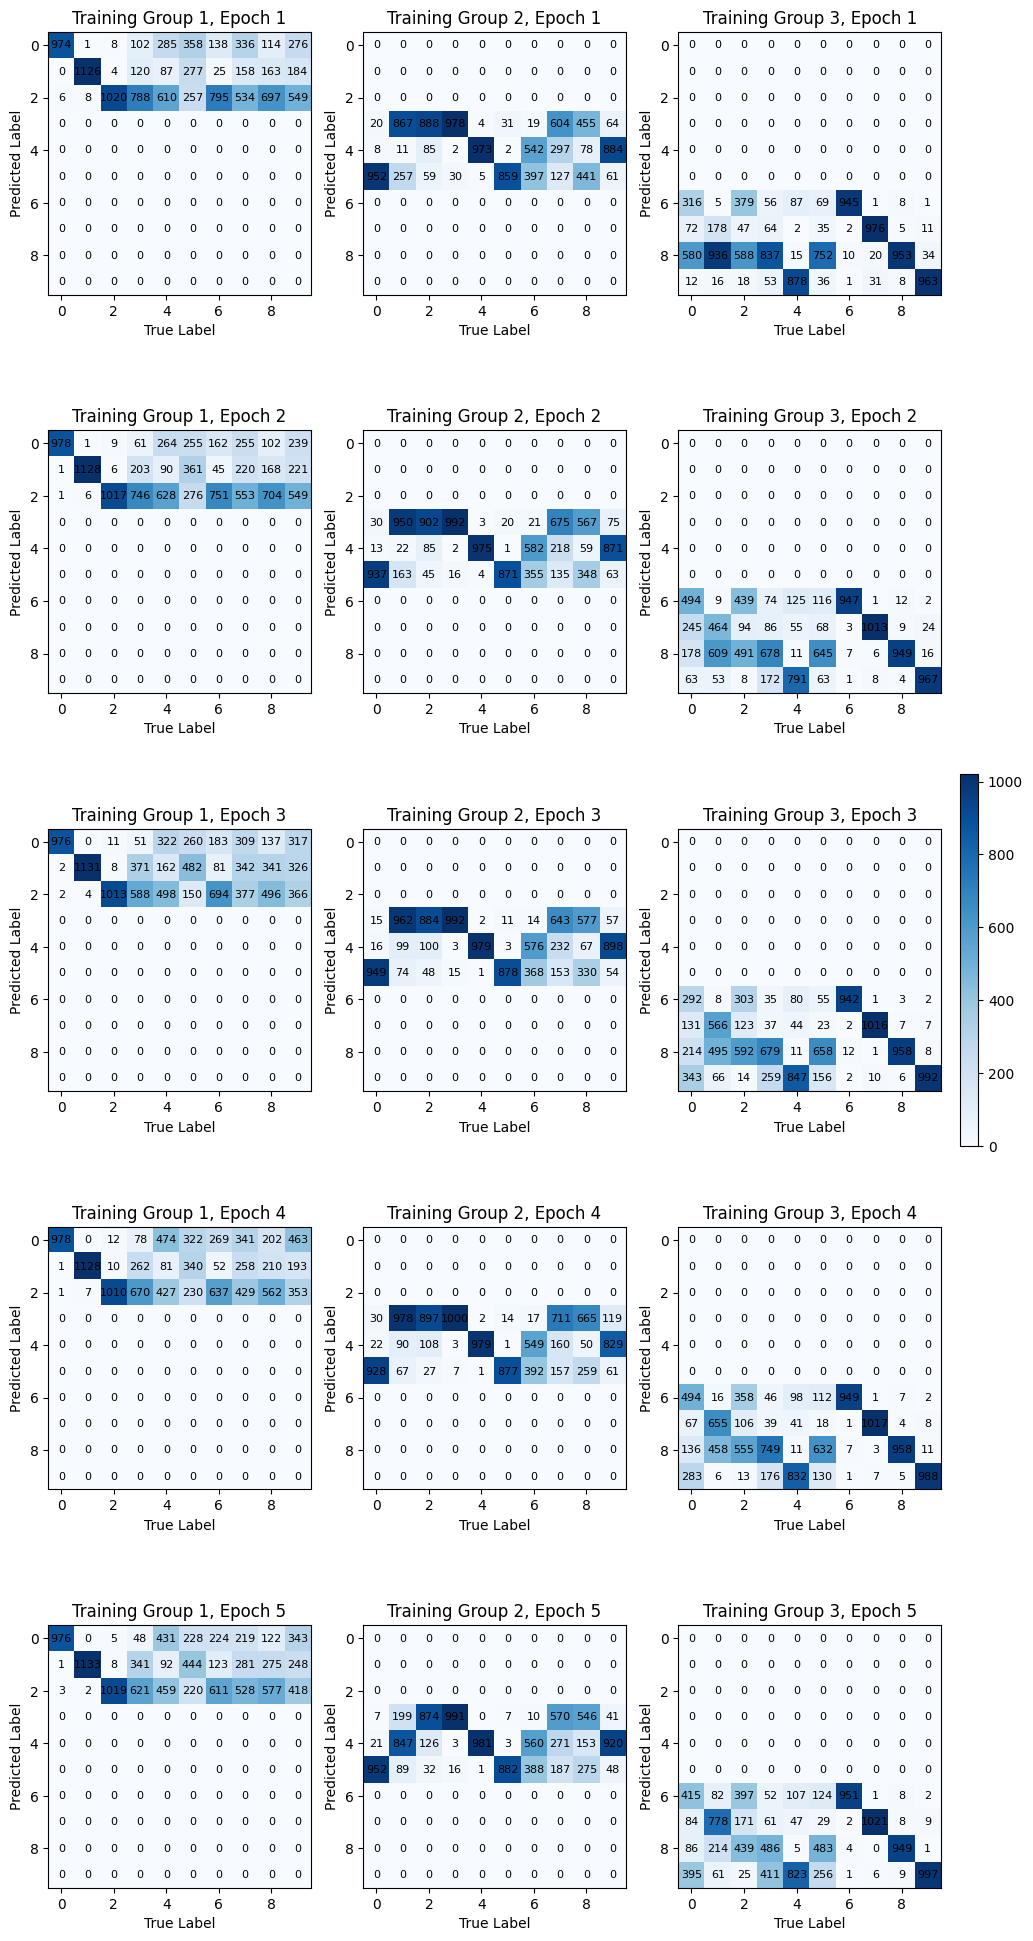

In [244]:
num_epochs, num_training_groups = len(cm_group_set[0]), len(cm_group_set)

num_rows, num_cols = num_epochs, num_training_groups

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols,
    figsize=(4 * num_cols, 5 * num_rows)
)

# Ensure axes is always 2D
axes = np.array(axes).reshape(num_rows, num_cols)

for m in range(num_cols):          # columns = data types
    for n in range(num_rows):     # rows = epochs

        ax = axes[n, m]
        cm = cm_group_set[m][n]

        im = ax.imshow(cm, cmap='Blues')

        # annotate cells
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i,
                    str(int(cm[i, j])),
                    ha='center',
                    va='center',
                    color='black',
                    fontsize=8
                )

        ax.set_title(f"Training Group {m+1}, Epoch {n+1}")

        ax.set_xlabel("True Label")
        ax.set_ylabel("Predicted Label")

# One shared colorbar (important)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)

plt.show()

### PCA Analyses of Penultimate Layer

In [245]:
μ, σ = compute_random_baseline(n_pca_components, n_samples=100_000, seed=42)

In [246]:
print(μ, σ)

0.09930267499286188 0.07446991020776277


In [247]:
cgm_cmap, cgm_norm = make_cgm_colormap(
    vmin=-2,
    vmax=12,
    neutral_low=-2,     # bottom of grey band = random mean
    neutral_high=2     # top of grey band    = 3σ above random mean
)
 
# Shared colorbar tick positions and labels
CGM_TICKS  = [-2, -1.3,         0,              2,        6,        9,       12]
CGM_LABELS = ['-2σ', '-1.3σ\n(min)', '0σ\n(mean)', '2σ', '6σ', '9σ', '12σ']
 

#### Comparing PCAs and Embeddings

In [248]:
cgm_set = []    

In [249]:
flattened_pca_set = np.reshape(pca_group_set, (-1))

for i in range(len(flattened_pca_set)-1):

    pca_A = flattened_pca_set[i].components_
    pca_B = flattened_pca_set[i+1].components_

    cgm_i = np.abs(np.matmul(pca_A, np.transpose(pca_B)))

    cgm_set.append(cgm_i)

In [250]:
z_cgm_set = []

In [251]:
for cgm in cgm_set:

    z_cgm = (cgm - μ)/σ

    z_cgm_set.append(z_cgm)

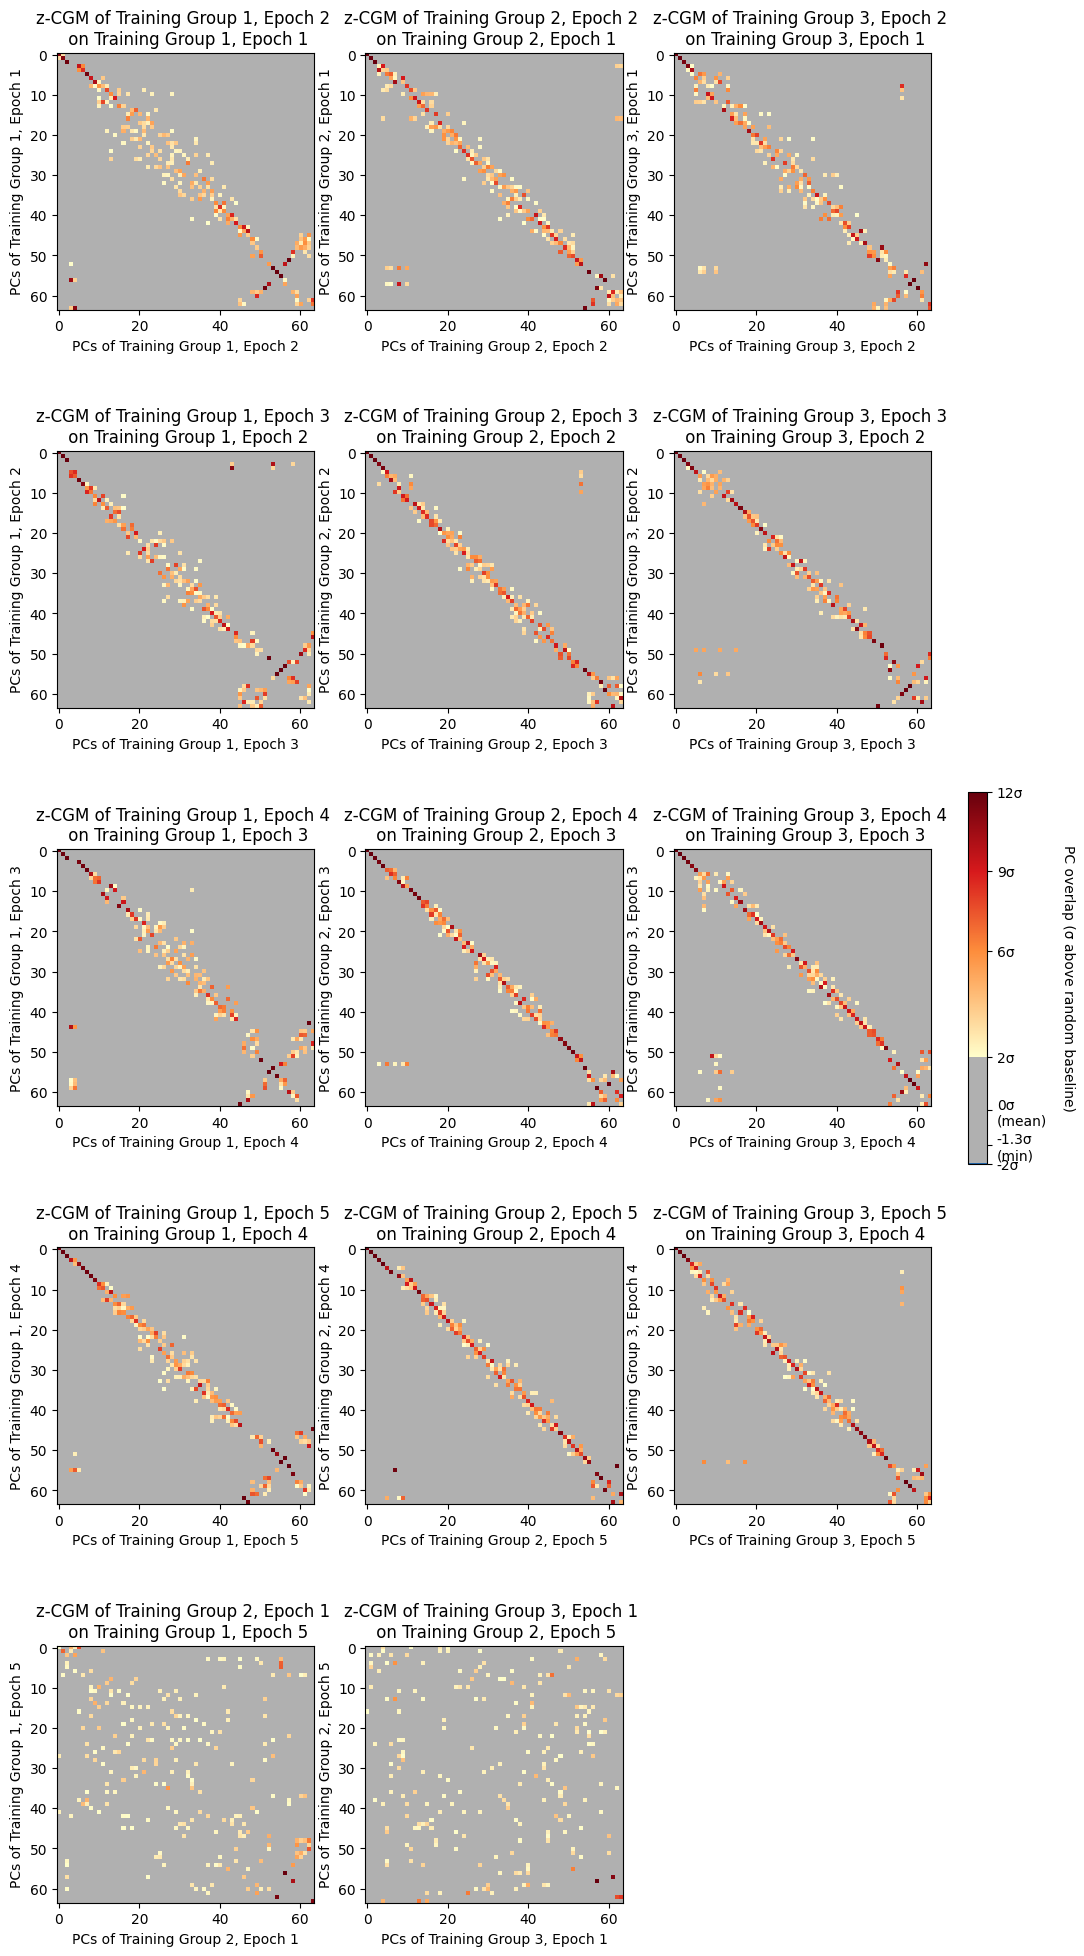

In [252]:
num_plots, num_rows, num_cols = len(flattened_pca_set), num_epochs, num_training_groups

fig, axes = plt.subplots(
    nrows=num_epochs,
    ncols=num_training_groups,
    figsize=(4 * num_training_groups, 5 * num_epochs)
)

# Ensure axes is always 2D
axes = np.array(axes).reshape(num_epochs, num_training_groups)

for plot in range(num_plots):

    g_earlier = plot//num_epochs
    g_later = (plot+1)//num_epochs
    e_earlier = plot%num_epochs
    e_later = (plot+1)%num_epochs

    ax = axes[e_earlier, g_earlier]

    if plot >= len(z_cgm_set):          # last cell has no CGM
        ax.axis("off")
        continue

    z_cgm = z_cgm_set[plot]

    im = ax.imshow(z_cgm, cmap=cgm_cmap, norm=cgm_norm)

    ax.set_title(f"z-CGM of Training Group {g_later+1}, Epoch {e_later+1} \n on Training Group {g_earlier+1}, Epoch {e_earlier+1}")

    ax.set_xlabel(f"PCs of Training Group {g_later+1}, Epoch {e_later+1}")
    ax.set_ylabel(f"PCs of Training Group {g_earlier+1}, Epoch {e_earlier+1}")

cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above random baseline)", rotation=270, labelpad=20)

plt.show()

In [258]:
dcgm_set = []    

In [259]:
for cgm in cgm_set:

    cost = 1 - cgm

    rows, cols = linear_sum_assignment(cost)

    dcgm = cgm[:, cols]

    dcgm_set.append(dcgm)

In [260]:
z_dcgm_set = []

In [261]:
for dcgm in dcgm_set:

    z_dcgm = (dcgm - μ)/σ

    z_dcgm_set.append(z_dcgm)

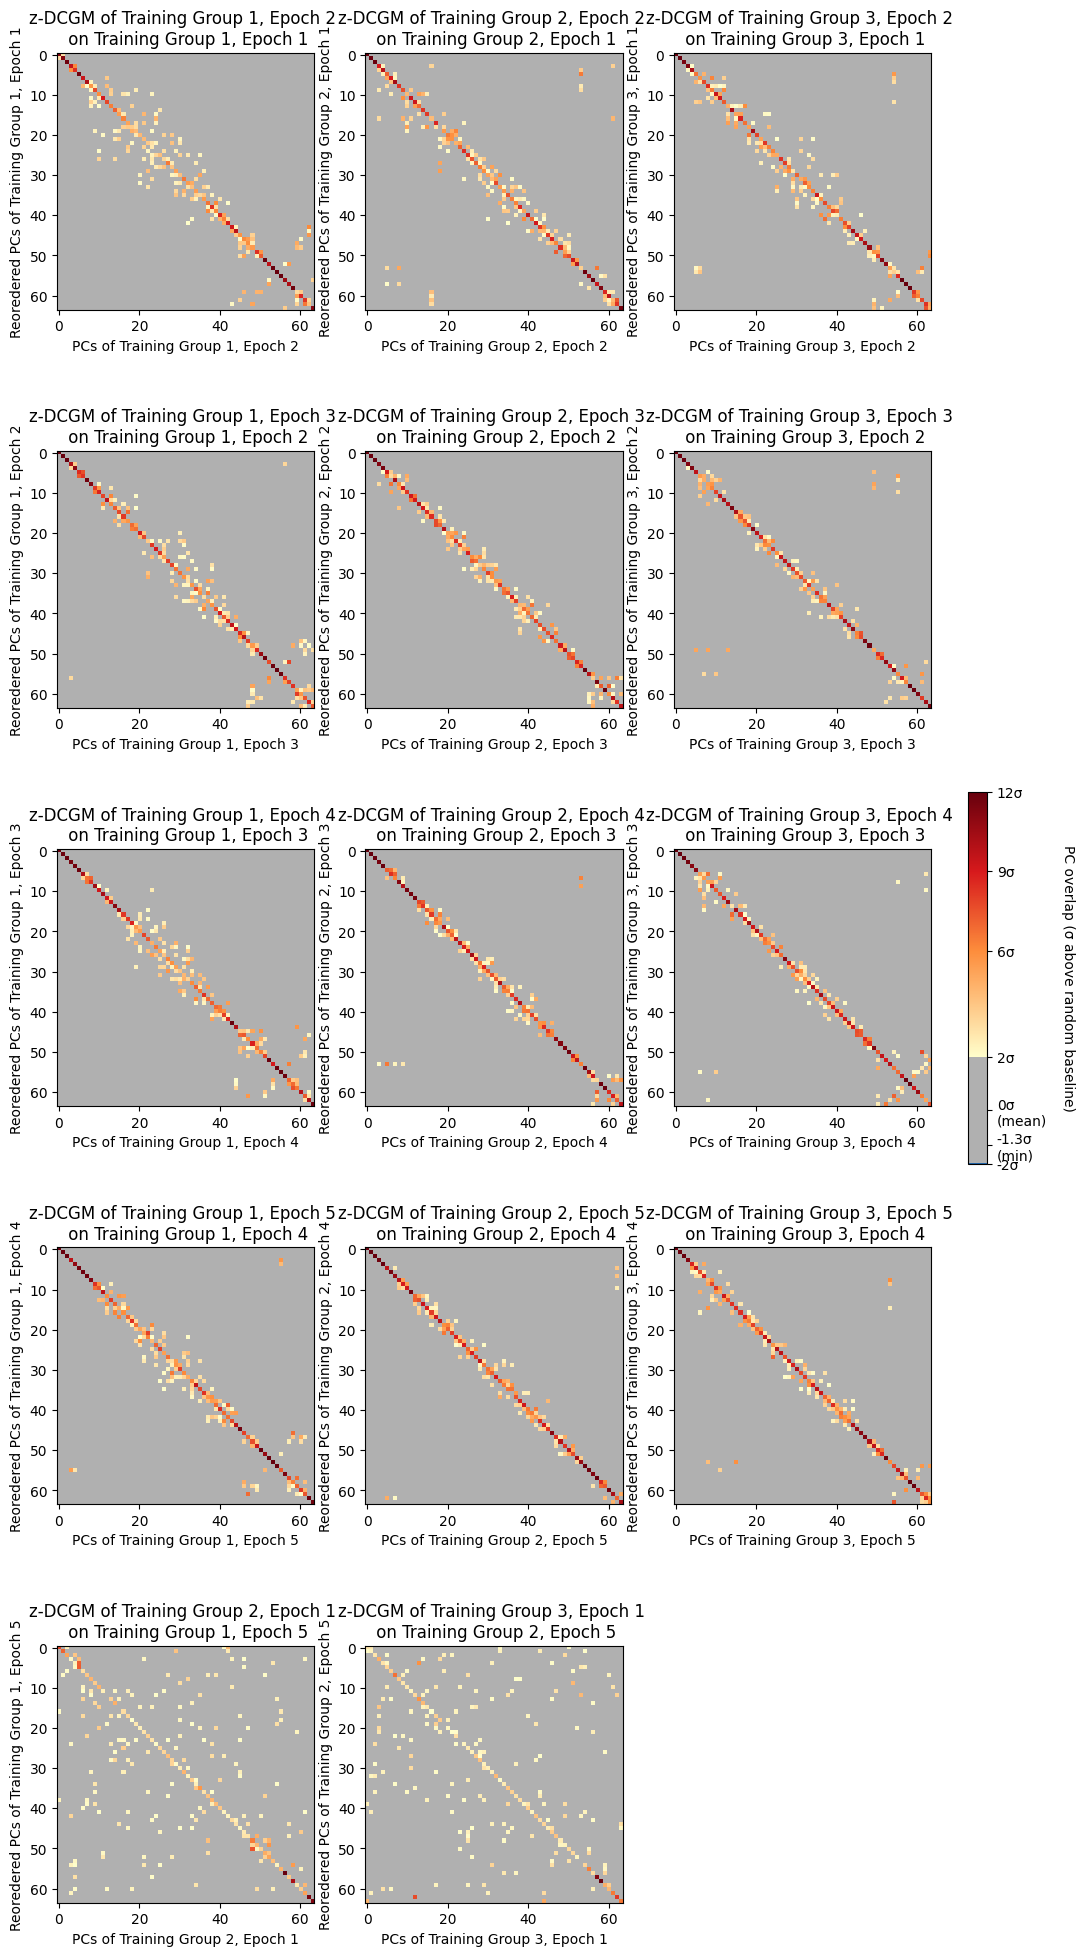

In [262]:
num_plots, num_rows, num_cols = len(flattened_pca_set), num_epochs, num_training_groups

fig, axes = plt.subplots(
    nrows=num_epochs,
    ncols=num_training_groups,
    figsize=(4 * num_training_groups, 5 * num_epochs)
)

# Ensure axes is always 2D
axes = np.array(axes).reshape(num_epochs, num_training_groups)

for plot in range(num_plots):

    g_earlier = plot//num_epochs
    g_later = (plot+1)//num_epochs
    e_earlier = plot%num_epochs
    e_later = (plot+1)%num_epochs

    ax = axes[e_earlier, g_earlier]

    if plot >= len(z_dcgm_set):          # last cell has no CGM
        ax.axis("off")
        continue

    z_dcgm = z_dcgm_set[plot]

    im = ax.imshow(z_dcgm, cmap=cgm_cmap, norm=cgm_norm)

    ax.set_title(f"z-DCGM of Training Group {g_later+1}, Epoch {e_later+1} \n on Training Group {g_earlier+1}, Epoch {e_earlier+1}")

    ax.set_xlabel(f"PCs of Training Group {g_later+1}, Epoch {e_later+1}")
    ax.set_ylabel(f"Reoredered PCs of Training Group {g_earlier+1}, Epoch {e_earlier+1}")

cbar = fig.colorbar(im, ax=axes, ticks=CGM_TICKS, fraction=0.02, pad=0.04)
cbar.ax.set_yticklabels(CGM_LABELS)
cbar.set_label("PC overlap (σ above random baseline)", rotation=270, labelpad=20)

plt.show()